<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Probability Basics for Naive Bayes</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Understand joint, marginal, and conditional probability.</li>
<li>Understand Bayes' Theorem and where it comes from.</li>
<li>Understand the concept of independence between events.</li>
<li>Build the foundation needed for Naive Bayes classification.</li>
</ol>
Naive Bayes is built entirely on probability theory.

 Before implementing 
the algorithm, I want to make sure I really understand the math behind it 
starting with the basics.
</div>

In [6]:
# Just basic libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>A Simple Example: Weather and Playing Tennis</b>
</h2>
<div style="font-family:'Times New Roman';">
To understand probability concepts, I'll use a small example dataset: 
whether someone plays tennis based on the weather (Sunny, Rainy, Overcast).
<br><br>
This is small enough to calculate everything by hand, which makes it 
perfect for building intuition.
</div>

In [7]:
# Creating a small dataset manually
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 
                'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Rainy',
                'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Play':    ['No', 'No', 'Yes', 'Yes', 'Yes', 
                'No', 'Yes', 'No', 'Yes', 'Yes',
                'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
df

,Weather,Play
0,Sunny,No
1,Sunny,No
2,Overcast,Yes
3,Rainy,Yes
4,Rainy,Yes
5,Rainy,No
6,Overcast,Yes
7,Sunny,No
8,Sunny,Yes
9,Rainy,Yes


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Marginal Probability</b>
</h2>
<div style="font-family:'Times New Roman';">
<b>Marginal probability</b> is just the probability of a single event 
happening, ignoring everything else.
<br><br>
For example: <b>P(Play = Yes)</b> -> "What fraction of all days did 
someone play tennis?"
<br><br>
It's calculated as:
<br>
<b>P(A) = (Number of times A happens) / (Total number of events)</b>
</div>

In [8]:
# Total number of observations
total = len(df)

# P(Play = Yes) and P(Play = No)
p_yes = (df['Play'] == 'Yes').sum() / total
p_no = (df['Play'] == 'No').sum() / total

print(f"P(Play = Yes) = {p_yes:.2f}")
print(f"P(Play = No)  = {p_no:.2f}")

# P(Weather = Sunny), P(Weather = Overcast), P(Weather = Rainy)
for weather in df['Weather'].unique():
    p_weather = (df['Weather'] == weather).sum() / total
    print(f"P(Weather = {weather}) = {p_weather:.2f}")

P(Play = Yes) = 0.64
P(Play = No)  = 0.36
P(Weather = Sunny) = 0.36
P(Weather = Overcast) = 0.29
P(Weather = Rainy) = 0.36


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Joint Probability</b>
</h2>
<div style="font-family:'Times New Roman';">
<b>Joint probability</b> is the probability of <b>two events happening 
together</b>.
<br><br>
For example: <b>P(Weather = Sunny AND Play = Yes)</b> -> "What fraction 
of all days was it both Sunny AND someone played tennis?"
<br><br>
It's calculated as:
<br>
<b>P(A and B) = (Number of times A and B both happen) / (Total number of events)</b>
</div>

In [9]:
# P(Weather = Sunny AND Play = Yes)
sunny_and_yes = ((df['Weather'] == 'Sunny') & (df['Play'] == 'Yes')).sum()
p_sunny_and_yes = sunny_and_yes / total

print(f"P(Weather = Sunny AND Play = Yes) = {p_sunny_and_yes:.2f}")

# Let's calculate this for all combinations using a cross-tabulation
joint_table = pd.crosstab(df['Weather'], df['Play'], normalize='all')
print("\nJoint Probability Table:")
joint_table

P(Weather = Sunny AND Play = Yes) = 0.14

Joint Probability Table:


Play,No,Yes
Weather,,
Overcast,0.000000,0.285714
Rainy,0.142857,0.214286
Sunny,0.214286,0.142857


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conditional Probability</b>
</h2>
<div style="font-family:'Times New Roman';">
<b>Conditional probability</b> is the probability of an event happening 
<b>given that another event has already happened</b>.
<br><br>
For example: <b>P(Play = Yes | Weather = Sunny)</b> -> "Given that it's 
Sunny, what's the probability that someone plays tennis?"
<br><br>
This is read as "<i>probability of Play=Yes given Weather=Sunny</i>" 
and is calculated as:
<br><br>
<b>P(A | B) = P(A and B) / P(B)</b>
<br><br>
In other words: out of all the days it was Sunny, how many of those 
days did someone play tennis?
</div>

In [10]:
# P(Play = Yes | Weather = Sunny)
# = P(Weather = Sunny AND Play = Yes) / P(Weather = Sunny)

p_sunny = (df['Weather'] == 'Sunny').sum() / total
p_sunny_and_yes = ((df['Weather'] == 'Sunny') & (df['Play'] == 'Yes')).sum() / total

p_yes_given_sunny = p_sunny_and_yes / p_sunny

print(f"P(Weather = Sunny)            = {p_sunny:.2f}")
print(f"P(Sunny AND Play = Yes)        = {p_sunny_and_yes:.2f}")
print(f"P(Play = Yes | Weather=Sunny)  = {p_yes_given_sunny:.2f}")

# A simpler, more direct way: just filter the data
sunny_days = df[df['Weather'] == 'Sunny']
direct_calc = (sunny_days['Play'] == 'Yes').sum() / len(sunny_days)

print(f"\nDirect calculation (filtering): {direct_calc:.2f}")

P(Weather = Sunny)            = 0.36
P(Sunny AND Play = Yes)        = 0.14
P(Play = Yes | Weather=Sunny)  = 0.40

Direct calculation (filtering): 0.40


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing Conditional Probability</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's visualize how the probability of playing tennis changes 
<b>depending on the weather</b>. This is exactly what conditional 
probability captures - the outcome "depends on" the condition.
</div>

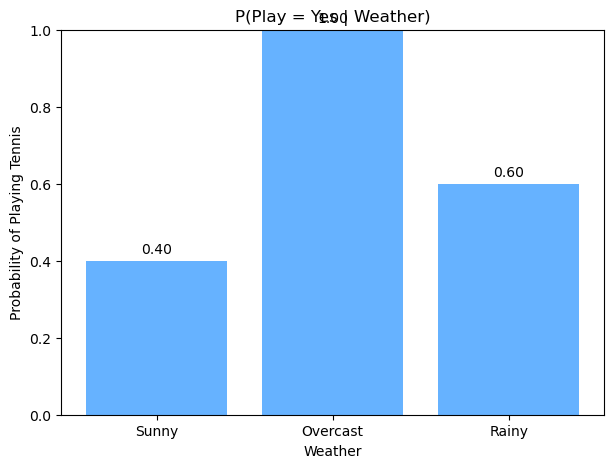

In [11]:
# Calculating P(Play = Yes | Weather = w) for each weather type
conditional_probs = {}

for weather in df['Weather'].unique():
    subset = df[df['Weather'] == weather]
    p_yes_given_weather = (subset['Play'] == 'Yes').sum() / len(subset)
    conditional_probs[weather] = p_yes_given_weather

# Plotting
plt.figure(figsize=(7, 5))
plt.bar(conditional_probs.keys(), conditional_probs.values(), color='#66B2FF')

plt.title("P(Play = Yes | Weather)")
plt.xlabel("Weather")
plt.ylabel("Probability of Playing Tennis")
plt.ylim(0, 1)

for weather, prob in conditional_probs.items():
    plt.text(weather, prob + 0.02, f"{prob:.2f}", ha='center')

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Independence Between Events</b>
</h2>
<div style="font-family:'Times New Roman';">
Two events <b>A</b> and <b>B</b> are called <b>independent</b> if 
knowing one of them gives us <b>no information</b> about the other.
<br><br>
Mathematically, A and B are independent if:
<br>
<b>P(A | B) = P(A)</b>
<br>
which also means:
<br>
<b>P(A and B) = P(A) × P(B)</b>
<br><br>
From our data above, <b>P(Play = Yes | Weather = Sunny)</b> was 
different from <b>P(Play = Yes)</b> overall - which means 
<b>Weather and Play are NOT independent</b>. Weather actually tells 
us something useful about whether someone plays tennis.
<br><br>
This makes sense - if Weather had <i>zero</i> relationship with Play, 
there would be no point using it as a feature at all!
</div>

In [12]:
# Comparing P(Play=Yes) with P(Play=Yes | Weather=Sunny)
print(f"P(Play = Yes)                  = {p_yes:.2f}")
print(f"P(Play = Yes | Weather=Sunny)  = {p_yes_given_sunny:.2f}")

if abs(p_yes - p_yes_given_sunny) < 1e-9:
    print("\nThese are equal -> Weather and Play appear INDEPENDENT")
else:
    print("\nThese are different -> Weather and Play are NOT independent")
    print("Knowing the weather changes our belief about whether someone plays tennis!")

P(Play = Yes)                  = 0.64
P(Play = Yes | Weather=Sunny)  = 0.40

These are different -> Weather and Play are NOT independent
Knowing the weather changes our belief about whether someone plays tennis!


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Deriving Bayes' Theorem</b>
</h2>
<div style="font-family:'Times New Roman';">
We already know the formula for conditional probability:
<br><br>
<b>P(A | B) = P(A and B) / P(B)</b>
<br><br>
But the joint probability P(A and B) can also be written the 
<i>other way around</i>:
<br><br>
<b>P(A and B) = P(B | A) × P(A)</b>
<br><br>
Substituting this into the first equation gives us 
<b>Bayes' Theorem</b>:
<br><br>
<b>P(A | B) = [ P(B | A) × P(A) ] / P(B)</b>
<br><br>
This is incredibly powerful because it lets us 
<b>"flip" a conditional probability</b>. If we know 
P(B | A), we can calculate P(A | B) - even if we never 
measured it directly.
<br><br>
In Naive Bayes, we'll use this to calculate things like:
<br>
<b>P(Play = Yes | Weather = Sunny) = [P(Weather = Sunny | Play = Yes) × P(Play = Yes)] / P(Weather = Sunny)</b>
</div>

In [13]:
# Let's verify Bayes' Theorem using our data
# We'll compute P(Play=Yes | Weather=Sunny) using Bayes' formula
# and compare it to the direct calculation we did earlier

# Step 1: P(Weather = Sunny | Play = Yes)
yes_days = df[df['Play'] == 'Yes']
p_sunny_given_yes = (yes_days['Weather'] == 'Sunny').sum() / len(yes_days)

# Step 2: P(Play = Yes) -> already calculated earlier as p_yes

# Step 3: P(Weather = Sunny) -> already calculated earlier as p_sunny

# Applying Bayes' Theorem
p_yes_given_sunny_bayes = (p_sunny_given_yes * p_yes) / p_sunny

print(f"P(Sunny | Yes) = {p_sunny_given_yes:.2f}")
print(f"P(Yes)         = {p_yes:.2f}")
print(f"P(Sunny)       = {p_sunny:.2f}")
print(f"\nP(Yes | Sunny) using Bayes' Theorem = {p_yes_given_sunny_bayes:.2f}")
print(f"P(Yes | Sunny) calculated directly   = {p_yes_given_sunny:.2f}")

if abs(p_yes_given_sunny_bayes - p_yes_given_sunny) < 1e-9:
    print("\nBoth values match! Bayes' Theorem checks out.")

P(Sunny | Yes) = 0.22
P(Yes)         = 0.64
P(Sunny)       = 0.36

P(Yes | Sunny) using Bayes' Theorem = 0.40
P(Yes | Sunny) calculated directly   = 0.40

Both values match! Bayes' Theorem checks out.


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>A Classic Bayes' Theorem Example: Medical Testing</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's look at a famous, slightly counter-intuitive example - it really 
drives home <b>why</b> Bayes' Theorem matters.
<br><br>
Suppose:
<ul>
<li>1% of people have a certain disease: <b>P(Disease) = 0.01</b></li>
<li>The test is 99% accurate for people who HAVE the disease: 
<b>P(Positive | Disease) = 0.99</b></li>
<li>The test also has a 5% false positive rate for healthy people: 
<b>P(Positive | No Disease) = 0.05</b></li>
</ul>
<b>Question:</b> If someone tests positive, what's the probability 
they actually have the disease - <b>P(Disease | Positive)</b>?
<br><br>
Most people guess "around 95%" because the test seems very accurate. 
Let's calculate the real answer using Bayes' Theorem.
</div>

In [14]:
# Given probabilities
p_disease = 0.01
p_no_disease = 1 - p_disease

p_positive_given_disease = 0.99
p_positive_given_no_disease = 0.05

# Step 1: Calculate P(Positive) using the law of total probability
# P(Positive) = P(Positive|Disease)*P(Disease) + P(Positive|No Disease)*P(No Disease)
p_positive = (p_positive_given_disease * p_disease) + \
              (p_positive_given_no_disease * p_no_disease)

# Step 2: Apply Bayes' Theorem
# P(Disease | Positive) = [P(Positive|Disease) * P(Disease)] / P(Positive)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"P(Positive) = {p_positive:.4f}")
print(f"P(Disease | Positive) = {p_disease_given_positive:.4f}")
print(f"\nThat's only about {p_disease_given_positive*100:.1f}% - much lower than most people expect!")

P(Positive) = 0.0594
P(Disease | Positive) = 0.1667

That's only about 16.7% - much lower than most people expect!


Total population: 10000
People with disease: 100
  -> Correctly tested positive (True Positives): 99
  -> Incorrectly tested negative (False Negatives): 1

People without disease: 9900
  -> Incorrectly tested positive (False Positives): 495
  -> Correctly tested negative (True Negatives): 9405

Total people who tested positive: 594
Of those, only 99 actually have the disease
P(Disease | Positive) = 99 / 594 = 0.1667


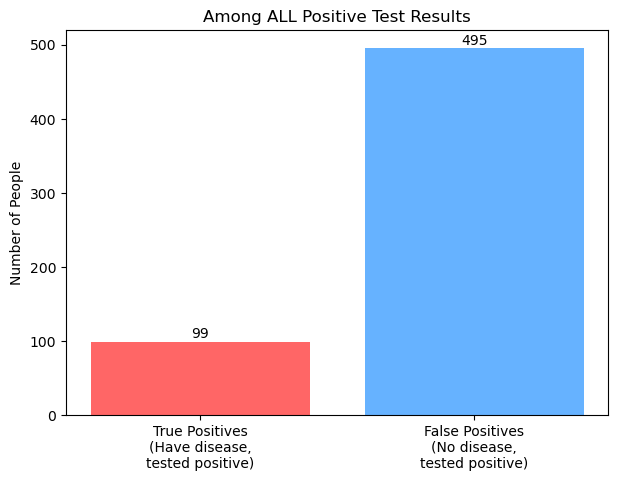

In [16]:
# Simulating a population of 10,000 people
population = 10000

actual_disease = int(population * p_disease)
actual_no_disease = population - actual_disease

# Among people WITH the disease
true_positives = int(actual_disease * p_positive_given_disease)
false_negatives = actual_disease - true_positives

# Among people WITHOUT the disease
false_positives = int(actual_no_disease * p_positive_given_no_disease)
true_negatives = actual_no_disease - false_positives

print(f"Total population: {population}")
print(f"People with disease: {actual_disease}")
print(f"  -> Correctly tested positive (True Positives): {true_positives}")
print(f"  -> Incorrectly tested negative (False Negatives): {false_negatives}")
print(f"\nPeople without disease: {actual_no_disease}")
print(f"  -> Incorrectly tested positive (False Positives): {false_positives}")
print(f"  -> Correctly tested negative (True Negatives): {true_negatives}")

print(f"\nTotal people who tested positive: {true_positives + false_positives}")
print(f"Of those, only {true_positives} actually have the disease")
print(f"P(Disease | Positive) = {true_positives} / {true_positives + false_positives} "
      f"= {true_positives / (true_positives + false_positives):.4f}")

# Visualizing as a bar chart
plt.figure(figsize=(7, 5))
categories = ['True Positives\n(Have disease,\ntested positive)', 
               'False Positives\n(No disease,\ntested positive)']
values = [true_positives, false_positives]

plt.bar(categories, values, color=['#FF6666', '#66B2FF'])
plt.title("Among ALL Positive Test Results")
plt.ylabel("Number of People")

for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li><b>Marginal Probability:</b> P(A) - probability of a single event, ignoring everything else.</li>
<li><b>Joint Probability:</b> P(A and B) - probability of two events happening together.</li>
<li><b>Conditional Probability:</b> P(A | B) - probability of A given that B has happened.</li>
<li><b>Independence:</b> A and B are independent if P(A | B) = P(A).</li>
<li><b>Bayes' Theorem:</b> P(A | B) = [P(B | A) × P(A)] / P(B) - lets us 
"flip" conditional probabilities.</li>
</ul>
This is exactly the foundation Naive Bayes is built on. The "Naive" part 
comes from <b>assuming features are independent of each other</b> (given 
the class) - which simplifies the math a lot, even though it's rarely 
true in real life.
<br><br>
Next, I'll move on to <b>implementing Naive Bayes from scratch</b> using 
these probability concepts.
</div>